

# Day 4: Statistical Tests + Time EDA + Feature Engineering

### Tasks

1. Hypothesis Testing
   - T-Test
   - ANOVA
   - Chi-Square Test

2. Time-Based EDA
   - Extract Year/Month/Day
   - Analyze Trends

3. Feature Engineering
   - Create 5+ New Features

4. Export Final Processed Dataset

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/interim/cleaned_day2.csv")

print("Shape:", df.shape)

df.head()

Shape: (87370, 31)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,14.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,14.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,14.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Hypothesis Testing

Hypothesis testing is a statistical technique used to determine whether an observed pattern or relationship in the data is statistically significant or has occurred by chance.

In this section, statistical tests are performed to validate business assumptions and uncover meaningful insights from hotel booking data.

The following tests will be conducted:

1. T-Test
2. ANOVA Test
3. Chi-Square Test

These tests will help identify significant differences and relationships among key business variables such as hotel type, pricing, market segments, and booking cancellations.


# 1. Independent T-Test

## What is a T-Test?

An Independent T-Test is a statistical method used to compare the mean values of a numerical variable between two independent groups.

The purpose of this test is to determine whether the observed difference between the group means is statistically significant or simply due to random variation.




 # ADR Comparison Between Hotel Types

## Business Context

Pricing is one of the most important factors influencing hotel revenue and profitability. Different hotel categories often adopt different pricing strategies based on their target customers, location, amenities, and demand patterns.

In this dataset, bookings are associated with two hotel categories:

* City Hotel
* Resort Hotel

Understanding whether these hotel types differ in their average room pricing can provide valuable insights into revenue management and market positioning.

---

## Problem Statement

Do City Hotels and Resort Hotels charge similar room rates, or is there a statistically significant difference in their Average Daily Rate (ADR)?

Answering this question helps us understand whether hotel category influences pricing behavior.

---

## Variables Considered

### Hotel Type (`hotel`)

A categorical variable representing the type of hotel where the booking was made.

Categories:

* City Hotel
* Resort Hotel

### Average Daily Rate (`adr`)

A numerical variable representing the average room rate charged per booking.

ADR is a key hospitality metric used to evaluate pricing performance and revenue generation.

---



## Objective

To determine whether the Average Daily Rate (ADR) differs significantly between City Hotels and Resort Hotels.

---

## Hypotheses

### Null Hypothesis (H₀)

There is no statistically significant difference in the mean ADR between City Hotels and Resort Hotels.

### Alternative Hypothesis (H₁)

There is a statistically significant difference in the mean ADR between City Hotels and Resort Hotels.

---

## Decision Rule

The test will be conducted at a significance level of **5% (α = 0.05)**.

* If **p-value < 0.05**, reject the Null Hypothesis.
* If **p-value ≥ 0.05**, fail to reject the Null Hypothesis.




In [4]:

from scipy.stats import ttest_ind


city_hotel_adr = df[df['hotel'] == 'City Hotel']['adr']
resort_hotel_adr = df[df['hotel'] == 'Resort Hotel']['adr']


t_statistic, p_value = ttest_ind(
    city_hotel_adr,
    resort_hotel_adr,
    nan_policy='omit'
)


print("Independent T-Test Results")
print("-" * 35)
print(f"T-Statistic : {t_statistic:.4f}")
print(f"P-Value     : {p_value:.10f}")

Independent T-Test Results
-----------------------------------
T-Statistic : 31.4473
P-Value     : 0.0000000000


## Results, Interpretation and Business Insights

### Observation

The Independent T-Test comparing the Average Daily Rate (ADR) between City Hotels and Resort Hotels produced a T-statistic of **31.4473** and a P-value of **0.0000**.

The exceptionally high T-statistic indicates a strong separation between the average ADR of the two hotel categories, while the near-zero P-value suggests that this difference is statistically significant.

### Statistical Interpretation

Since the P-value is less than the chosen significance level of 0.05, the Null Hypothesis (H₀) is rejected.

This provides strong statistical evidence that the Average Daily Rate (ADR) differs significantly between City Hotels and Resort Hotels. Therefore, the variation in room pricing observed across hotel types is unlikely to be due to random chance.

### Key Findings

* A statistically significant difference exists in ADR between City Hotels and Resort Hotels.
* Hotel category has a measurable impact on room pricing.
* The difference observed is substantial, as indicated by the large T-statistic.
* Pricing behavior is not uniform across hotel types.

### Business Insights

The findings suggest that City Hotels and Resort Hotels operate under different pricing structures and revenue strategies.

Several factors may contribute to this difference, including:

* Differences in target customer segments.
* Variations in location and accessibility.
* Seasonal demand fluctuations.
* Distinct service offerings and amenities.
* Different revenue management and pricing policies.

Understanding these pricing differences can help hotel managers refine pricing strategies, optimize revenue generation, and better align room rates with customer demand patterns.

### Conclusion

Based on the results of the Independent T-Test, hotel type is a significant factor influencing Average Daily Rate (ADR). The analysis confirms that City Hotels and Resort Hotels exhibit distinct pricing behavior, making hotel category an important variable in revenue and pricing analysis.




## Lead Time vs Cancellation Status

### What is Being Tested?

This test examines whether there is a significant difference in the booking lead time between canceled and non-canceled bookings.

### Why Are We Performing This Test?

Lead Time represents the number of days between the booking date and the arrival date.

Customers who book well in advance may have more opportunities to change their travel plans, potentially increasing the likelihood of cancellation.

Understanding this relationship can help hotels improve demand forecasting, reservation planning, and cancellation management strategies.

### Variables Used

#### Cancellation Status (`is_canceled`)

This variable indicates whether a booking was canceled.

* 0 → Not Canceled
* 1 → Canceled

#### Lead Time (`lead_time`)

Lead Time represents the number of days between booking creation and the guest's arrival date.

### Objective

To determine whether canceled bookings and non-canceled bookings have significantly different lead times.

### Hypotheses

#### Null Hypothesis (H₀)

There is no significant difference in the mean lead time between canceled and non-canceled bookings.

#### Alternative Hypothesis (H₁)

There is a significant difference in the mean lead time between canceled and non-canceled bookings.

### Significance Level

α = 0.05

* If p-value < 0.05 → Reject H₀
* If p-value ≥ 0.05 → Fail to Reject H₀


In [5]:
from scipy.stats import ttest_ind

cancelled = df[df['is_canceled'] == 1]['lead_time']
not_cancelled = df[df['is_canceled'] == 0]['lead_time']

t_statistic, p_value = ttest_ind(
    cancelled,
    not_cancelled,
    nan_policy='omit'
)

print("Independent T-Test Results")
print("-" * 35)
print(f"T-Statistic : {t_statistic:.4f}")
print(f"P-Value     : {p_value:.10f}")

Independent T-Test Results
-----------------------------------
T-Statistic : 55.5462
P-Value     : 0.0000000000


In [6]:
df.groupby('is_canceled')['lead_time'].agg(
    ['mean', 'median', 'min', 'max']
)

,mean,median,min,max
is_canceled,,,,
0,70.123859,38.0,0,737
1,105.720030,80.0,0,629


## Results and Interpretation

### Test Results

The Independent T-Test produced the following results:

* **T-Statistic:** 55.5462
* **P-Value:** 0.0000

### Understanding the Results

The T-statistic measures the difference between the average lead times of canceled and non-canceled bookings relative to the variability within each group.

A T-statistic of **55.5462** is exceptionally large, indicating a substantial difference in lead time between the two booking categories.

The P-value is effectively **0.0000**, which is significantly lower than the chosen significance level of **0.05**. This suggests that the observed difference is extremely unlikely to have occurred by random chance.

### Statistical Decision

Since:

**P-Value (0.0000) < α (0.05)**

the **Null Hypothesis (H₀)** is rejected.

### Key Findings

The average lead time for each group is:

| Cancellation Status | Mean Lead Time (Days) |
| ------------------- | --------------------: |
| Not Cancelled       |                 70.12 |
| Cancelled           |                105.72 |

Customers who cancelled their bookings had a considerably higher average lead time compared to customers who completed their bookings.

### Interpretation

The analysis indicates a statistically significant difference in booking lead time between canceled and non-canceled reservations.

Bookings that are made far in advance are more likely to be cancelled compared to bookings made closer to the arrival date.

This relationship suggests that longer planning horizons may increase the likelihood of itinerary changes, resulting in higher cancellation rates.

### Business Insight

Lead time appears to be a strong indicator of cancellation behavior.

Customers who book several months in advance have more opportunities to modify travel plans, compare alternatives, or cancel reservations altogether.

This insight can help hotels:

* Improve cancellation forecasting.
* Develop more accurate demand predictions.
* Optimize overbooking strategies.
* Design targeted cancellation policies for high lead-time reservations.

### Conclusion

Based on the T-Test results, there is strong statistical evidence that lead time differs significantly between canceled and non-canceled bookings.

Customers who cancel their reservations tend to book substantially earlier than those who ultimately complete their stay, making lead time an important factor in understanding cancellation behavior.




# Average Daily Rate (ADR) vs Cancellation Status

### Business Context

Room pricing is one of the most important revenue drivers in the hospitality industry. Hotels continuously adjust room rates based on demand, seasonality, customer segments, and market conditions.

Understanding whether booking cancellations are associated with room pricing can provide valuable insights into customer behavior and revenue management.

---

## Problem Statement

Do customers who cancel their bookings pay different room rates compared to customers who complete their reservations?

Answering this question can help determine whether pricing influences cancellation behavior.

---

## Variables Considered

### Cancellation Status (`is_canceled`)

A categorical variable indicating whether a booking was cancelled.

Categories:

* 0 → Not Cancelled
* 1 → Cancelled

### Average Daily Rate (`adr`)

A numerical variable representing the average room rate charged per booking.

ADR is a key performance indicator used to measure hotel pricing and revenue generation.

---



## Objective

To determine whether there is a statistically significant difference in the Average Daily Rate (ADR) between cancelled and non-cancelled bookings.

---

## Hypotheses

### Null Hypothesis (H₀)

There is no statistically significant difference in the mean ADR between cancelled and non-cancelled bookings.

### Alternative Hypothesis (H₁)

There is a statistically significant difference in the mean ADR between cancelled and non-cancelled bookings.

---

## Decision Rule

The test will be conducted at a significance level of **5% (α = 0.05)**.

* If **p-value < 0.05**, reject the Null Hypothesis.
* If **p-value ≥ 0.05**, fail to reject the Null Hypothesis.


In [8]:
from scipy.stats import ttest_ind

cancelled_adr = df[df['is_canceled'] == 1]['adr']
not_cancelled_adr = df[df['is_canceled'] == 0]['adr']

t_statistic, p_value = ttest_ind(
    cancelled_adr,
    not_cancelled_adr,
    nan_policy='omit'
)

print("Independent T-Test Results")
print("-" * 35)
print(f"T-Statistic : {t_statistic:.4f}")
print(f"P-Value     : {p_value:.10f}")

Independent T-Test Results
-----------------------------------
T-Statistic : 38.1344
P-Value     : 0.0000000000


In [9]:
df.groupby('is_canceled')['adr'].agg(
    ['mean', 'median', 'min', 'max']
)

,mean,median,min,max
is_canceled,,,,
0,102.012692,94.5,-6.38,510.0
1,117.775380,109.8,0.00,5400.0


## Results and Interpretation

### Test Results

The Independent T-Test produced the following results:

* **T-Statistic:** 38.1344
* **P-Value:** 0.0000

### Understanding the Results

The T-statistic measures the difference between the average ADR of cancelled and non-cancelled bookings relative to the variation within each group.

A T-statistic of **38.1344** indicates a substantial difference between the average room rates of the two booking categories.

The P-value is effectively **0.0000**, which is significantly lower than the significance level of **0.05**. This indicates that the observed difference is highly unlikely to have occurred by random chance.

### Statistical Decision

Since:

**P-Value (0.0000) < α (0.05)**

the **Null Hypothesis (H₀)** is rejected.

### Key Findings

The average ADR for each group is:

| Cancellation Status | Mean ADR |
| ------------------- | -------: |
| Not Cancelled       |   102.01 |
| Cancelled           |   117.78 |

Cancelled bookings have a noticeably higher average room rate compared to bookings that were successfully completed.

### Interpretation

The analysis indicates a statistically significant difference in ADR between cancelled and non-cancelled bookings.

Customers associated with higher-priced bookings appear to cancel reservations more frequently than customers with lower-priced bookings.

This suggests that room pricing may influence booking commitment and cancellation behavior.

### Business Insights

The findings highlight a potential relationship between room price and cancellation risk.

Several factors may contribute to this pattern:

* Higher-priced bookings may involve longer planning horizons.
* Customers paying premium rates may compare alternative options before travel.
* Expensive reservations may be more sensitive to changes in travel plans.
* Premium bookings may face greater cancellation uncertainty.

Understanding this relationship can help hotels identify high-risk reservations and improve revenue management strategies.

### Conclusion

Based on the Independent T-Test results, there is strong statistical evidence that Average Daily Rate (ADR) differs significantly between cancelled and non-cancelled bookings.

The analysis suggests that higher-priced bookings are associated with a greater likelihood of cancellation, making ADR an important factor when evaluating cancellation behavior and revenue risk.


# 4. Analysis of Variance (ANOVA)

## What is ANOVA?

Analysis of Variance (ANOVA) is a statistical test used to compare the mean values of a numerical variable across three or more independent groups.

While an Independent T-Test compares the means of two groups, ANOVA extends this concept to multiple groups simultaneously.

The primary purpose of ANOVA is to determine whether the observed differences among group means are statistically significant or simply the result of random variation.

ANOVA helps answer the question:

**"Do all groups have similar average values, or does at least one group differ significantly from the others?"**


# ADR Across Market Segments

## Variables Used

### Market Segment (`market_segment`)

A categorical variable representing different customer booking segments such as Direct, Online TA, Corporate, Groups, and Offline TA/TO.

### Average Daily Rate (`adr`)

A numerical variable representing the average room rate charged per booking and a key indicator of hotel pricing performance and revenue generation.

## Why These Variables?

Different customer segments often exhibit different booking behaviors, spending patterns, and purchasing preferences.

As a result, room pricing may vary across market segments. Analyzing ADR across these groups helps identify high-value customer segments and evaluate pricing effectiveness across booking channels.

## Objective

To determine whether the Average Daily Rate (ADR) differs significantly across different market segments.

## Hypotheses

### Null Hypothesis (H₀)

The mean ADR is equal across all market segments.

### Alternative Hypothesis (H₁)

At least one market segment has a mean ADR that differs significantly from the others.

## Decision Rule

* If **p-value < 0.05**, reject H₀.
* If **p-value ≥ 0.05**, fail to reject H₀.


In [10]:
from scipy.stats import f_oneway


market_segments = [
    group['adr'].values
    for name, group in df.groupby('market_segment')
]


f_statistic, p_value = f_oneway(*market_segments)

print("ANOVA Test Results")
print("-" * 35)
print(f"F-Statistic : {f_statistic:.4f}")
print(f"P-Value     : {p_value:.10f}")

ANOVA Test Results
-----------------------------------
F-Statistic : 2247.8289
P-Value     : 0.0000000000


In [11]:
market_segment_summary = (
    df.groupby('market_segment')['adr']
      .agg(['mean', 'median', 'count'])
      .sort_values('mean', ascending=False)
)

market_segment_summary

,mean,median,count
market_segment,,,
Online TA,118.167680,110.700,51615
Direct,116.595481,106.735,11798
Aviation,100.170396,95.000,227
Offline TA/TO,81.773430,79.055,13886
Groups,74.821719,68.000,4940
Corporate,68.231568,65.000,4202
Complementary,3.049245,0.000,702


## Results and Interpretation

### Test Results

The One-Way ANOVA test produced the following results:

* **F-Statistic:** 2247.8289
* **P-Value:** 0.0000

### Understanding the Results

The **F-statistic** measures the variation between group means relative to the variation within each group.

A large F-statistic indicates that the differences among group means are substantially greater than the variation observed within the groups.

In this analysis, the F-statistic of **2247.8289** is exceptionally high, suggesting considerable variation in ADR across different market segments.

The **P-value** is effectively zero and is significantly lower than the chosen significance level of 0.05. This indicates that the observed differences are highly unlikely to have occurred due to random chance.

### Statistical Decision

Since:

**P-Value (0.0000) < α (0.05)**

the **Null Hypothesis (H₀)** is rejected.

### Key Findings

The average ADR varies considerably across market segments.

The highest average ADR values were observed in:

* Online TA (118.17)
* Direct (116.60)
* Aviation (100.17)

The lowest average ADR values were observed in:

* Corporate (68.23)
* Groups (74.82)
* Complementary (3.05)

These differences indicate that customer segments exhibit distinct pricing patterns.

### Interpretation

The ANOVA results provide strong statistical evidence that the Average Daily Rate (ADR) is not the same across all market segments.

At least one market segment has a significantly different average room rate compared to the others.

This suggests that customer acquisition channels and booking segments play an important role in hotel pricing and revenue generation.

### Business Insights

The analysis highlights notable differences in customer value across market segments.

* Online Travel Agency (OTA) and Direct bookings generate the highest average room rates.
* Corporate and Group bookings tend to be associated with lower ADR values.
* Complementary bookings have extremely low ADR values, which is expected since these bookings are often promotional or provided at little to no cost.

These findings can support:

* Revenue optimization strategies
* Customer segment targeting
* Pricing policy evaluation
* Marketing channel performance assessment

### Conclusion

Based on the One-Way ANOVA results, there is strong statistical evidence that Average Daily Rate (ADR) differs significantly across market segments.

Therefore, market segment is an important factor influencing hotel pricing and should be considered when developing revenue management and customer acquisition strategies.


# 5. Chi-Square Test

## What is a Chi-Square Test?

The Chi-Square Test of Independence is a statistical test used to determine whether there is a significant association between two categorical variables.

Unlike T-Tests and ANOVA, which compare numerical values across groups, the Chi-Square Test evaluates whether two categorical variables are related to each other.

The test helps answer the question:

**"Are the two categorical variables independent, or is there a significant relationship between them?"**


## Variables, Objective and Hypotheses

### Variables Used

**Hotel Type (`hotel`)**

* City Hotel
* Resort Hotel

**Cancellation Status (`is_canceled`)**

* 0 → Not Cancelled
* 1 → Cancelled

### Why These Variables?

Booking cancellations directly impact hotel revenue, occupancy planning, and forecasting accuracy.

Analyzing the relationship between hotel type and cancellation status helps determine whether cancellation behavior differs across hotel categories.

### Objective

To determine whether hotel type and booking cancellation status are associated.

### Hypotheses

**H₀ (Null Hypothesis)**
Hotel type and cancellation status are independent.

**H₁ (Alternative Hypothesis)**
Hotel type and cancellation status are associated.

### Decision Rule

* If **p-value < 0.05**, reject H₀.
* If **p-value ≥ 0.05**, fail to reject H₀.


In [14]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(
    df['hotel'],
    df['is_canceled']
)

# Perform Chi-Square Test
chi2_statistic, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Test Results")
print("-" * 35)
print(f"Chi-Square Statistic : {chi2_statistic:.4f}")
print(f"P-Value              : {p_value:.10f}")
print(f"Degrees of Freedom   : {dof}")

Chi-Square Test Results
-----------------------------------
Chi-Square Statistic : 445.6835
P-Value              : 0.0000000000
Degrees of Freedom   : 1


In [15]:
pd.crosstab(
    df['hotel'],
    df['is_canceled'],
    normalize='index'
) * 100

is_canceled,0,1
hotel,,
City Hotel,69.960319,30.039681
Resort Hotel,76.505421,23.494579


## Results and Interpretation

### Test Results

The Chi-Square Test produced the following results:

* **Chi-Square Statistic:** 445.6835
* **P-Value:** 0.0000
* **Degrees of Freedom:** 1

### Understanding the Results

#### Chi-Square Statistic

The Chi-Square Statistic measures the difference between the observed frequencies and the frequencies that would be expected if the two variables were completely independent.

A larger Chi-Square value indicates a stronger deviation from independence and suggests a stronger association between the variables.

In this analysis, the Chi-Square Statistic is **445.6835**, indicating a substantial difference between the observed and expected frequencies.

#### P-Value

The P-Value represents the probability of observing such a difference if the Null Hypothesis were true.

The obtained P-Value is **0.0000**, which is significantly lower than the significance level of **0.05**.

This indicates that the observed association is highly unlikely to have occurred due to random chance.

#### Degrees of Freedom

Degrees of Freedom represent the number of independent comparisons that can be made in the contingency table.

For this test:

**Degrees of Freedom = 1**

This is expected because both variables contain two categories:

* Hotel Type → City Hotel, Resort Hotel
* Cancellation Status → Cancelled, Not Cancelled

### Statistical Decision

Since:

**P-Value (0.0000) < α (0.05)**

the **Null Hypothesis (H₀)** is rejected.

### Key Findings

The cancellation percentages are:

| Hotel Type   | Not Cancelled (%) | Cancelled (%) |
| ------------ | ----------------: | ------------: |
| City Hotel   |             69.96 |         30.04 |
| Resort Hotel |             76.51 |         23.49 |

City Hotels exhibit a higher cancellation rate compared to Resort Hotels.

### Interpretation

The Chi-Square Test indicates a statistically significant association between hotel type and booking cancellation status.

This means that cancellation behavior is not independent of hotel type. The likelihood of a booking being cancelled varies depending on whether the reservation was made at a City Hotel or a Resort Hotel.

### Business Insights

The analysis suggests that City Hotels experience higher cancellation rates than Resort Hotels.

Possible reasons may include:

* Greater booking flexibility among city travelers.
* Higher proportion of business and short-term bookings.
* Increased competition and alternative accommodation options in urban locations.
* More frequent changes in travel plans among city hotel customers.

Understanding these differences can help hotel managers improve cancellation forecasting, optimize reservation policies, and develop targeted retention strategies.

### Conclusion

Based on the Chi-Square Test results, there is strong statistical evidence of an association between hotel type and cancellation status.

Therefore, hotel type is an important factor influencing booking cancellation behavior within this dataset.


# 6. Time-Based Exploratory Data Analysis

## Introduction

Time-based analysis helps uncover booking trends, seasonal patterns, and changes in customer demand over time.

By analyzing date-related information, we can identify peak booking periods, seasonal fluctuations, and temporal patterns that influence hotel reservations.

This section focuses on extracting and analyzing time-based features to gain insights into booking behavior across different periods.


## Date Feature Extraction

To perform time-based analysis, the separate year, month, and day columns are combined into a single date column.

This enables easier analysis of booking trends, seasonal patterns, and temporal changes over time.


In [16]:
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_day_of_month'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_year'].astype(str),
    format='%d-%B-%Y'
)

df[['arrival_date']].head()

,arrival_date
0,2015-07-01
1,2015-07-01
2,2015-07-01
3,2015-07-01
4,2015-07-01


## Extracting Time Components

To enable time-based trend analysis, individual components are extracted from the arrival date.

These components help analyze booking patterns across years, months, and days, providing insights into seasonal trends and customer demand fluctuations.


In [17]:
df['arrival_year'] = df['arrival_date'].dt.year
df['arrival_month'] = df['arrival_date'].dt.month
df['arrival_day'] = df['arrival_date'].dt.day

df[['arrival_date',
    'arrival_year',
    'arrival_month',
    'arrival_day']].head()

,arrival_date,arrival_year,arrival_month,arrival_day
0,2015-07-01,2015,7,1
1,2015-07-01,2015,7,1
2,2015-07-01,2015,7,1
3,2015-07-01,2015,7,1
4,2015-07-01,2015,7,1


## Monthly Booking Trend

Understanding how bookings vary across different months helps identify seasonal demand patterns and peak booking periods.

Analyzing monthly booking trends can provide valuable insights into customer behavior and hotel demand throughout the year.


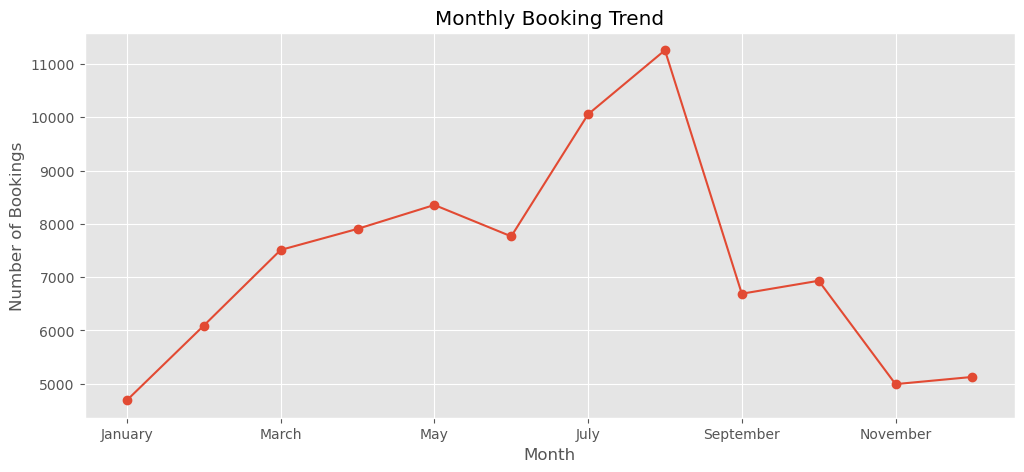

In [22]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_bookings = (
    df['arrival_date_month']
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(12,5))

monthly_bookings.plot(
    kind='line',
    marker='o'
)

plt.title('Monthly Booking Trend')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.grid(True)

plt.show()

## Results and Interpretation

### Key Findings

* Booking volume increases steadily from January to May.
* A slight decline is observed during June.
* Demand rises sharply during July and August.
* August records the highest number of bookings.
* Booking activity decreases significantly after August and remains relatively lower during the final months of the year.

### Interpretation

The monthly booking trend reveals a clear seasonal pattern in hotel demand.

Booking activity gradually increases during the first half of the year and reaches its peak during the summer months, particularly in July and August.

Following the peak season, booking volume declines and remains comparatively lower toward the end of the year.

### Business Insights

* July and August represent peak-demand periods for hotel bookings.
* Hotels may benefit from dynamic pricing strategies during high-demand months.
* Additional staffing and operational resources may be required during peak seasons.
* Promotional campaigns can be introduced during lower-demand months to improve occupancy rates.

### Conclusion

The analysis indicates strong seasonality in hotel bookings, with demand peaking during the mid-year months and declining during the latter part of the year. Understanding these patterns can support better planning, pricing, and resource management decisions.


## Monthly Booking Trends by Year

Analyzing monthly booking patterns across different years helps identify seasonal consistency and variations in customer demand over time.

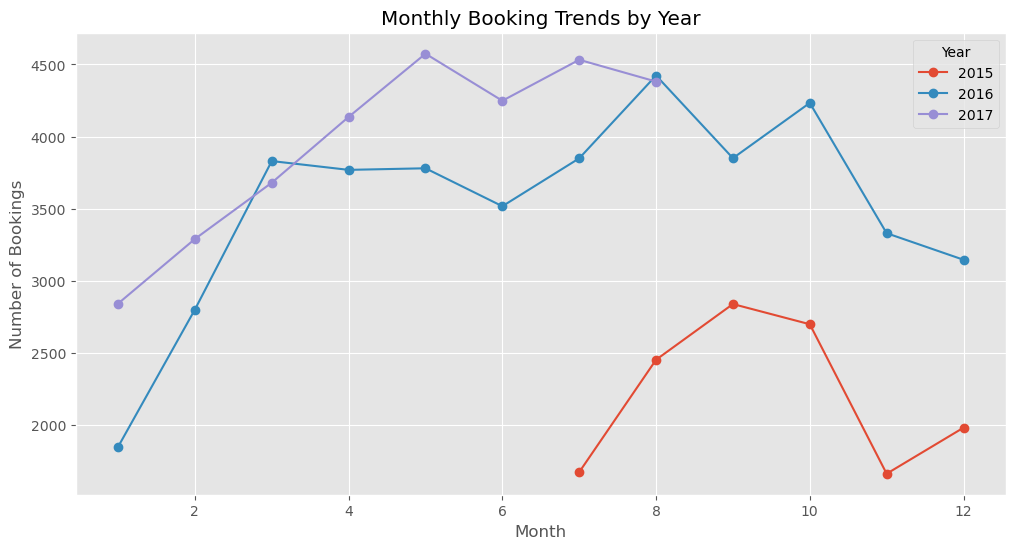

In [23]:
monthly_yearly = (
    df.groupby(['arrival_year', 'arrival_month'])
      .size()
      .reset_index(name='bookings')
)

plt.figure(figsize=(12,6))

for year in sorted(monthly_yearly['arrival_year'].unique()):
    data = monthly_yearly[
        monthly_yearly['arrival_year'] == year
    ]

    plt.plot(
        data['arrival_month'],
        data['bookings'],
        marker='o',
        label=year
    )

plt.title('Monthly Booking Trends by Year')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.legend(title='Year')
plt.grid(True)

plt.show()

## Results and Interpretation

### Key Findings

* Booking volumes vary across months in all three years.
* Similar seasonal patterns can be observed, with higher booking activity during the middle months of the year.
* Booking demand generally increases during spring and summer months and declines toward the end of the year.
* The trend indicates recurring seasonal behavior in hotel reservations.

### Interpretation

The monthly booking trends reveal that customer demand is influenced by seasonal factors across multiple years.

Although the total number of bookings differs between years, the overall pattern remains relatively consistent, with demand increasing during peak travel periods and decreasing during off-peak seasons.

### Business Insights

* Seasonal demand patterns are evident across the dataset.
* Peak-demand months may support dynamic pricing and revenue optimization strategies.
* Hotels can use these patterns for staffing, inventory management, and operational planning.
* Lower-demand periods provide opportunities for targeted marketing campaigns and promotional offers.

### Conclusion

The analysis highlights recurring seasonal trends in hotel bookings across different years. Understanding these patterns can help hotels improve forecasting accuracy and make more informed business decisions.


## Average Daily Rate (ADR) by Month

Analyzing the Average Daily Rate (ADR) across different months helps identify seasonal pricing patterns and fluctuations in room rates throughout the year.

This analysis provides insights into how hotel pricing changes in response to seasonal demand and customer booking behavior.


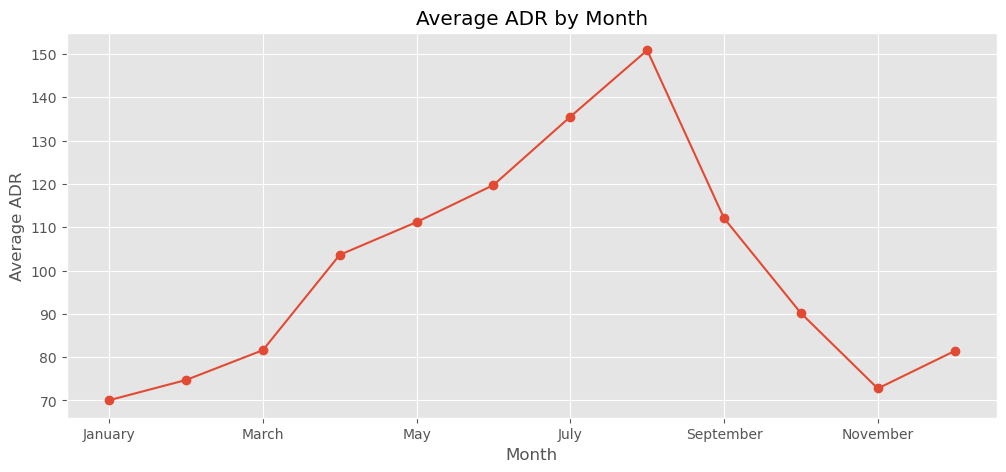

In [24]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_adr = (
    df.groupby('arrival_date_month')['adr']
      .mean()
      .reindex(month_order)
)

plt.figure(figsize=(12,5))

monthly_adr.plot(
    kind='line',
    marker='o'
)

plt.title('Average ADR by Month')
plt.xlabel('Month')
plt.ylabel('Average ADR')
plt.grid(True)

plt.show()

## Results and Interpretation

### Key Findings

- Average ADR increases steadily from January to August.
- August records the highest average ADR, exceeding 150.
- ADR declines sharply after August and continues to decrease during the remaining months.
- The lowest ADR values are observed during January and November.

### Interpretation

The trend indicates a strong seasonal pricing pattern in hotel room rates.

As customer demand increases during the middle months of the year, hotels tend to charge higher room rates. The highest ADR observed during July and August coincides with the peak booking season identified in the previous analysis.

Following the peak season, average room rates decrease significantly, reflecting lower demand and reduced pricing pressure.

### Business Insights

- Peak-demand months allow hotels to charge premium room rates.
- August represents both the highest booking demand and the highest average room rate, indicating strong revenue potential.
- Lower ADR values during off-peak months may require promotional pricing strategies to attract customers.
- Understanding seasonal pricing patterns can support revenue optimization and dynamic pricing decisions.

### Conclusion

The analysis reveals a clear relationship between seasonality and hotel pricing. Average room rates increase during high-demand periods and decrease during lower-demand periods, demonstrating the impact of seasonal demand on hotel revenue generation.

## Feature 1: Total Guests

### Description

The total number of guests is calculated by combining adults, children, and babies associated with each booking.

### Purpose

This feature represents the overall party size and provides a more complete measure of the number of guests included in a reservation.

In [25]:
df['total_guests'] = (
    df['adults'] +
    df['children'] +
    df['babies']
)

df[['adults',
    'children',
    'babies',
    'total_guests']].head()

,adults,children,babies,total_guests
0,2,0.0,0,2.0
1,2,0.0,0,2.0
2,1,0.0,0,1.0
3,1,0.0,0,1.0
4,2,0.0,0,2.0


### Observation

A new feature named `total_guests` was created by combining the number of adults, children, and babies associated with each booking.

### Insight

This feature provides a single measure of the total party size, making it easier to analyze guest composition and booking behavior without examining multiple columns separately.

### Business Value

The total number of guests can be useful for identifying customer groups, analyzing occupancy patterns, and understanding how group size influences booking characteristics.

## Feature 2: Total Nights

### Description

The total duration of stay is calculated by combining weekday nights and weekend nights.

### Purpose

This feature represents the complete length of a guest's stay and provides a more meaningful measure of booking duration.

In [26]:
df['total_nights'] = (
    df['stays_in_week_nights'] +
    df['stays_in_weekend_nights']
)

df[['stays_in_week_nights',
    'stays_in_weekend_nights',
    'total_nights']].head()

,stays_in_week_nights,stays_in_weekend_nights,total_nights
0,0,0,0
1,0,0,0
2,1,0,1
3,1,0,1
4,2,0,2


### Observation

A new feature named `total_nights` was created by combining weekday stays and weekend stays.

### Insight

This feature represents the complete duration of a guest's stay and provides a single measure of booking length.

### Business Value

The total number of nights is an important indicator of customer behavior and can help analyze stay patterns, occupancy trends, and revenue generation.

## Feature 3: Total Previous Bookings

### Description

The total number of previous bookings is calculated by combining previously cancelled bookings and previously completed bookings.

### Purpose

This feature provides a consolidated measure of a customer's booking history.

In [27]:
df['total_previous_bookings'] = (
    df['previous_cancellations'] +
    df['previous_bookings_not_canceled']
)

df[['previous_cancellations',
    'previous_bookings_not_canceled',
    'total_previous_bookings']].head()

,previous_cancellations,previous_bookings_not_canceled,total_previous_bookings
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


### Observation

A new feature named `total_previous_bookings` was created by combining previous cancellations and previous successful bookings.

In the displayed sample records, the values are zero, indicating that these particular customers had no prior booking history with the hotel.

### Insight

This feature provides a unified measure of a customer's historical interaction with the hotel by capturing both cancelled and completed bookings in a single variable.

### Business Value

Customer booking history can help identify repeat customers, understand loyalty patterns, and analyze how previous booking behavior influences future reservations.

## Feature 4: Total Booking Value

### Description

The total booking value is estimated by multiplying the Average Daily Rate (ADR) by the total number of nights booked.

### Purpose

This feature provides an estimate of the revenue generated by each booking and combines pricing information with stay duration into a single business metric.

In [31]:
df['total_booking_value'] = (
    df['adr'] * df['total_nights']
)

df[['adr',
    'total_nights',
    'total_booking_value']].head()

,adr,total_nights,total_booking_value
0,0.0,0,0.0
1,0.0,0,0.0
2,75.0,1,75.0
3,75.0,1,75.0
4,98.0,2,196.0


### Observation

A new feature named `total_booking_value` was created by multiplying the Average Daily Rate (ADR) by the total number of nights booked.

The feature represents the estimated value generated by each reservation.

In the displayed sample records, bookings with longer stays or higher ADR values produce larger booking values.

### Insight

Neither ADR nor stay duration alone provides a complete picture of the economic value of a booking.

By combining pricing and stay duration into a single variable, the feature provides a more meaningful representation of the revenue potential associated with each reservation.

### Business Value

The `total_booking_value` feature serves as an approximate revenue indicator and can help identify high-value bookings, profitable customer segments, and revenue-generating booking patterns.

This feature is particularly useful for revenue analysis, customer segmentation, and business decision-making.

## Feature 5: Room Changed

### Description

A binary feature is created to indicate whether the room assigned to a guest differs from the room originally reserved.

### Purpose

This feature helps identify situations where room allocation was modified during the booking process and may provide insights into hotel operations and room management.

In [32]:
df['room_changed'] = (
    df['reserved_room_type'] != df['assigned_room_type']
).astype(int)

df[['reserved_room_type',
    'assigned_room_type',
    'room_changed']].head()

,reserved_room_type,assigned_room_type,room_changed
0,C,C,0
1,C,C,0
2,A,C,1
3,A,A,0
4,A,A,0


### Observation

A new feature named `room_changed` was created by comparing the reserved room type and assigned room type.

Bookings where the assigned room differs from the reserved room were assigned a value of 1, while bookings where both room types are the same were assigned a value of 0.

In the displayed sample records, most bookings received the originally reserved room, while one booking was assigned a different room type.

### Insight

This feature captures room allocation changes that occur between reservation and check-in.

A room change may indicate room upgrades, room downgrades, operational adjustments, overbooking management, or room availability constraints.

### Business Value

The `room_changed` feature provides insights into hotel room management practices and operational efficiency.

It can help identify patterns related to room reallocations and may support analyses involving customer satisfaction, occupancy management, and hotel operations.

## Feature 6: Family Booking

### Description

A binary feature is created to identify whether a booking includes children or babies.

### Purpose

This feature helps distinguish family travelers from non-family travelers and supports customer segmentation analysis.

In [33]:
df['family_booking'] = (
    (df['children'] + df['babies']) > 0
).astype(int)

df[['children',
    'babies',
    'family_booking']].head()

,children,babies,family_booking
0,0.0,0,0
1,0.0,0,0
2,0.0,0,0
3,0.0,0,0
4,0.0,0,0


### Observation

A new feature named `family_booking` was created using the number of children and babies associated with each reservation.

Bookings containing at least one child or baby were assigned a value of 1, while bookings without children or babies were assigned a value of 0.

In the displayed sample records, all bookings are classified as non-family bookings.

### Insight

This feature transforms guest composition information into a simple customer-segmentation variable.

Rather than analyzing children and babies separately, the feature directly identifies whether a booking represents a family traveler segment.

### Business Value

Family travelers often exhibit different booking patterns, stay durations, room preferences, and spending behavior compared to other guests.

The `family_booking` feature can support customer segmentation, targeted marketing strategies, and comparative analysis of guest behavior.

## Feature 7: Long Stay

### Description

A binary feature is created to identify bookings with a stay duration of seven nights or more.

### Purpose

This feature helps distinguish long-term stays from shorter visits and supports stay-duration analysis.

In [34]:
df['long_stay'] = (
    df['total_nights'] >= 7
).astype(int)

df[['total_nights',
    'long_stay']].head()

,total_nights,long_stay
0,0,0
1,0,0
2,1,0
3,1,0
4,2,0


### Observation

A new feature named `long_stay` was created from the `total_nights` variable.

Bookings with a stay duration of seven nights or more were assigned a value of 1, while bookings with fewer than seven nights were assigned a value of 0.

In the displayed sample records, all bookings are classified as short stays because their stay durations are below the defined threshold.

### Insight

This feature transforms continuous stay-duration information into a categorical indicator representing short-term and long-term stays.

Rather than focusing on the exact number of nights, the feature highlights whether a booking belongs to the long-stay segment.

### Business Value

Long-stay guests often exhibit different booking behavior, revenue contribution, and accommodation requirements compared to short-stay guests.

The `long_stay` feature can support customer segmentation, occupancy planning, revenue analysis, and stay-duration studies.

In [35]:
df.to_csv(
    '../data/processed/final_cleaned_day4.csv',
    index=False
)

print("Final Day 4 dataset saved successfully.")

Final Day 4 dataset saved successfully.


In [36]:
import os

os.path.exists('../data/processed/final_cleaned_day4.csv')

True

# 9. Final Insights and Conclusion

## Statistical Testing Insights

- Independent T-Tests revealed statistically significant differences in ADR and lead time across selected customer groups.
- ANOVA analysis confirmed that average ADR differs significantly across market segments.
- The Chi-Square test indicated a significant relationship between hotel type and booking cancellation behavior.

## Time-Based Analysis Insights

- Hotel bookings exhibit clear seasonal patterns throughout the year.
- Booking demand peaks during the middle months of the year, particularly July and August.
- Similar seasonal trends are observed across different years.
- Average ADR increases during high-demand periods, indicating the impact of seasonality on hotel pricing.

## Feature Engineering Insights

Seven new features were created to enhance the dataset:

1. total_guests
2. total_nights
3. total_previous_bookings
4. total_booking_value
5. room_changed
6. family_booking
7. long_stay

These features provide additional insights into customer behavior, booking value, stay characteristics, hotel operations, and customer segmentation.

## Conclusion

The dataset was successfully prepared through statistical analysis, time-based exploration, and feature engineering.

The generated insights reveal meaningful relationships between customer behavior, booking characteristics, pricing patterns, and hotel operations.

The final processed dataset is now suitable for advanced analytics, predictive modeling, and machine learning applications.